# 🦟 Pipeline Modelo Dengue Colombia

**Estructura del análisis:**
- **TRAIN:** 2009–2019 (11 años, pre-pandemia)
- **SKIP:** 2020–2021 (pandemia)
- **TEST:** 2022–2024

**Fuentes integradas:**
- SIVIGILA (casos dengue, microdatos individuales)
- DANE (proyecciones de población municipal)
- SRTM/Open-Elevation (altitud municipal)
- DIVIPOLA (códigos oficiales de municipios)

## Paso 1 — Instalar dependencias

In [ ]:
!pip install requests pandas openpyxl gdown tqdm scipy --quiet

## Paso 2 — Importar librerías y configuración global

In [ ]:
import pandas as pd
import numpy as np
import requests
import gdown
import io
import os
from scipy.spatial import cKDTree
from tqdm import tqdm

# ── Configuración ─────────────────────────────────────────────────────────────
CARPETA_SIVIGILA = 'sivigila_raw/SIVIGILA descarga manual 2009 a 2024/'
AÑOS_TRAIN       = list(range(2009, 2020))   # 2009–2019
AÑOS_SKIP        = [2020, 2021]              # pandemia — omitir
AÑOS_TEST        = [2022, 2023, 2024]        # test
FILE_ID_ALT      = '1-oDjgHJha25pXWnZMWHv6-3iwhu26qUz'
FOLDER_ID_SIV    = '1ejjaYYLysIuWHOpLC6-lN-AaBg-MgNgH'

# Columnas que usaremos de cada archivo SIVIGILA
COLS_SIVIGILA = ['COD_EVE', 'ANO', 'SEMANA', 'INI_SIN',
                 'COD_DPTO_O', 'COD_MUN_O', 'TIP_CAS', 'EDAD', 'SEXO']

print('✅ Configuración cargada')
print(f'   TRAIN: {AÑOS_TRAIN}')
print(f'   TEST : {AÑOS_TEST}')
print(f'   SKIP : {AÑOS_SKIP}')

✅ Configuración cargada
   TRAIN: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
   TEST : [2022, 2023, 2024]
   SKIP : [2020, 2021]


## Paso 3 — Descargar archivos SIVIGILA desde Drive

In [ ]:
if not os.path.exists(CARPETA_SIVIGILA):
    print('Descargando carpeta SIVIGILA desde Drive...')
    gdown.download_folder(
        f'https://drive.google.com/drive/folders/{FOLDER_ID_SIV}',
        output='sivigila_raw/',
        quiet=False
    )
    print('✅ Descarga completada')
else:
    print('✅ Carpeta ya existe, usando archivos locales')

archivos = sorted([f for f in os.listdir(CARPETA_SIVIGILA)
                   if f.endswith(('.xls', '.xlsx'))])
print(f'\nArchivos disponibles ({len(archivos)}):')
for f in archivos:
    año = int(f.split('_')[1])
    tag = '🟢 TRAIN' if año in AÑOS_TRAIN else ('🔴 SKIP' if año in AÑOS_SKIP else '🔵 TEST')
    size = os.path.getsize(f'{CARPETA_SIVIGILA}{f}') / (1024*1024)
    print(f'  {tag} {f} ({size:.1f} MB)')

Descargando carpeta SIVIGILA desde Drive...


Retrieving folder contents


Processing file 1d18nAMk2MWODqjxmXhhPNbgstS9Mn1y- Datos_2009_210.xls
Processing file 1LqUe9MoUc3zR_YRhR3oefFPf78DU1MKt Datos_2010_210.xlsx
Processing file 1tibQzNt6uspgLmpMv67gdCxRo_D7r6bF Datos_2011_210.xls
Processing file 1f2ZLMS7t7NMW9KrACAEv9EY9HbckW0sS Datos_2012_210.xls
Processing file 1MoZMy2DSvsF3xZZLx1LujedHjAZ_hI0a Datos_2013_210.xlsx
Processing file 1qw44O1b7215eE-PLgcYSE88_GVOSjvh1 Datos_2014_210.xlsx
Processing file 1j2eqV6bxS-s5MArz0RMzlnMo1kjanYoQ Datos_2015_210.xlsx
Processing file 1O_GCunhfWNVxqiSP7j-3_f578UtWss5F Datos_2016_210.xlsx
Processing file 1SUdyLw5ZiUJqz2MzzhLcT4kIap4-vra0 Datos_2017_210.xls
Processing file 186mzmoIesprrOdM-8tGrGlPuD52hIAYz Datos_2018_210.xls
Processing file 1_1dOgQBE1fIGCafVn3vL9oP-0YdnqEFT Datos_2019_210.xlsx
Processing file 1KQWniGb2OgsnU467l0ReXpv_9w59EZm- Datos_2020_210.xlsx
Processing file 1jqA6bgprt0NWftXLN67nyxaeMAd_HS8P Datos_2021_210.xls
Processing file 1gi2hoGzEjt4HRn3qCy8cNrY_Ij2OXlE0 Datos_2022_210.xlsx
Processing file 1Gwc--kJMD

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1d18nAMk2MWODqjxmXhhPNbgstS9Mn1y-
To: /content/sivigila_raw/SIVIGILA descarga manual 2009 a 2024/Datos_2009_210.xls
100%|██████████| 49.7M/49.7M [00:00<00:00, 158MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1LqUe9MoUc3zR_YRhR3oefFPf78DU1MKt
From (redirected): https://drive.google.com/uc?id=1LqUe9MoUc3zR_YRhR3oefFPf78DU1MKt&confirm=t&uuid=31da9fcd-8d2e-4820-ba6c-1b2f2e74092d
To: /content/sivigila_raw/SIVIGILA descarga manual 2009 a 2024/Datos_2010_210.xlsx
100%|██████████| 49.4M/49.4M [00:00<00:00, 226MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tibQzNt6uspgLmpMv67gdCxRo_D7r6bF
To: /content/sivigila_raw/SIVIGILA descarga manual 2009 a 2024/Datos_2011_210.xls
100%|██████████| 32.3M/32.3M [00:00<00:00, 182MB/s]
Downloading...
From: https://drive.google.com/uc?id=1f2ZLMS7t7NMW9KrACAEv9EY9HbckW0sS
T

✅ Descarga completada

Archivos disponibles (16):
  🟢 TRAIN Datos_2009_210.xls (47.4 MB)
  🟢 TRAIN Datos_2010_210.xlsx (47.1 MB)
  🟢 TRAIN Datos_2011_210.xls (30.8 MB)
  🟢 TRAIN Datos_2012_210.xls (54.8 MB)
  🟢 TRAIN Datos_2013_210.xlsx (38.3 MB)
  🟢 TRAIN Datos_2014_210.xlsx (32.3 MB)
  🟢 TRAIN Datos_2015_210.xlsx (29.6 MB)
  🟢 TRAIN Datos_2016_210.xlsx (32.8 MB)
  🟢 TRAIN Datos_2017_210.xls (26.0 MB)
  🟢 TRAIN Datos_2018_210.xls (45.5 MB)
  🟢 TRAIN Datos_2019_210.xlsx (38.8 MB)
  🔴 SKIP Datos_2020_210.xlsx (24.5 MB)
  🔴 SKIP Datos_2021_210.xls (51.4 MB)
  🔵 TEST Datos_2022_210.xlsx (20.3 MB)
  🔵 TEST Datos_2023_210.xlsx (41.7 MB)
  🔵 TEST Datos_2024_210.xlsx (87.1 MB)



Download completed


## Paso 4 — Cargar y unir archivos SIVIGILA

In [ ]:
dfs_train = []
dfs_test  = []

for archivo in tqdm(archivos, desc='Leyendo archivos'):
    año = int(archivo.split('_')[1])

    if año in AÑOS_SKIP:
        print(f'  ⏭ {año} omitido (pandemia)')
        continue

    ruta = f'{CARPETA_SIVIGILA}{archivo}'
    try:
        df_temp = pd.read_excel(ruta, usecols=lambda c: c in COLS_SIVIGILA)
        for col in COLS_SIVIGILA:
            if col not in df_temp.columns:
                df_temp[col] = np.nan
        df_temp = df_temp[COLS_SIVIGILA].copy()
        df_temp['_año_archivo'] = año

        if año in AÑOS_TRAIN:
            dfs_train.append(df_temp)
        elif año in AÑOS_TEST:
            dfs_test.append(df_temp)
    except Exception as e:
        print(f'  ❌ Error en {archivo}: {e}')

df_train_raw = pd.concat(dfs_train, ignore_index=True)
df_test_raw  = pd.concat(dfs_test,  ignore_index=True)

print(f'\nTRAIN: {len(df_train_raw):,} registros individuales')
print(f'TEST : {len(df_test_raw):,} registros individuales')

Leyendo archivos:  69%|██████▉   | 11/16 [06:05<02:55, 35.17s/it]

  ⏭ 2020 omitido (pandemia)
  ⏭ 2021 omitido (pandemia)


Leyendo archivos: 100%|██████████| 16/16 [10:03<00:00, 37.73s/it]


TRAIN: 889,700 registros individuales
TEST : 501,729 registros individuales


## Paso 5 — Limpiar y estandarizar SIVIGILA

In [ ]:
def limpiar_sivigila(df):
    df = df.copy()

    # Código municipio DIVIPOLA 5 dígitos
    df['cod_municipio'] = (
        pd.to_numeric(df['COD_DPTO_O'], errors='coerce')
        .astype('Int64').astype(str).str.replace('<NA>', '').str.zfill(2) +
        pd.to_numeric(df['COD_MUN_O'], errors='coerce')
        .astype('Int64').astype(str).str.replace('<NA>', '').str.zfill(3)
    )

    # Tipo de caso
    df['tipo_dengue'] = df['TIP_CAS'].map({
        1: 'sin_alarma',
        2: 'con_alarma',
        3: 'grave'
    }).fillna('sin_clasificar')

    # Año y semana epidemiológica
    df['anio']       = pd.to_numeric(df['ANO'],    errors='coerce')
    df['semana_epi'] = pd.to_numeric(df['SEMANA'], errors='coerce')

    # Fecha inicio síntomas
    df['ini_sin'] = pd.to_datetime(df['INI_SIN'], errors='coerce')

    # Eliminar municipios inválidos
    df = df[~df['cod_municipio'].isin(['00000', '<NA><NA>', 'NaNNaN'])]
    df = df.dropna(subset=['anio', 'semana_epi'])

    return df[['cod_municipio', 'anio', 'semana_epi',
               'ini_sin', 'tipo_dengue', 'EDAD', 'SEXO']]

df_train_clean = limpiar_sivigila(df_train_raw)
df_test_clean  = limpiar_sivigila(df_test_raw)

print(f'TRAIN limpio: {len(df_train_clean):,} | municipios: {df_train_clean["cod_municipio"].nunique()}')
print(f'TEST  limpio: {len(df_test_clean):,}  | municipios: {df_test_clean["cod_municipio"].nunique()}')
print()
print('Distribución tipo de caso (TRAIN):')
print(df_train_clean['tipo_dengue'].value_counts())

TRAIN limpio: 889,142 | municipios: 1132
TEST  limpio: 501,729  | municipios: 1037

Distribución tipo de caso (TRAIN):
tipo_dengue
con_alarma        660978
grave             191178
sin_clasificar     36986
Name: count, dtype: int64


## Paso 6 — Agregar casos por municipio, año y semana epidemiológica

In [ ]:
def agregar_casos(df):
    return (
        df.groupby(['cod_municipio', 'anio', 'semana_epi', 'tipo_dengue'])
        .size()
        .reset_index(name='casos')
    )

agg_train = agregar_casos(df_train_clean)
agg_test  = agregar_casos(df_test_clean)

print(f'TRAIN agregado: {len(agg_train):,} filas')
print(f'TEST  agregado: {len(agg_test):,} filas')
print()
print('Casos por año (TRAIN):')
print(agg_train.groupby('anio')['casos'].sum().to_string())

TRAIN agregado: 186,400 filas
TEST  agregado: 76,169 filas

Casos por año (TRAIN):
anio
2009     45264
2010    147081
2011     29101
2012     52467
2013    122439
2014    105356
2015     95010
2016    100098
2017     25043
2018     43648
2019    123635


## Paso 7 — Cargar altitud municipal (SRTM)

In [ ]:
# Descargar archivo de altitud desde Drive
ARCHIVO_ALTITUD = 'municipios_colombia_altitud.csv'
if not os.path.exists(ARCHIVO_ALTITUD):
    print('Descargando archivo de altitud...')
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID_ALT}',
                   ARCHIVO_ALTITUD, quiet=False)
else:
    print('✅ Archivo de altitud ya existe')

df_alt = pd.read_csv(ARCHIVO_ALTITUD)[['latitud','longitud','altitud_msnm','cat_altitud']].dropna()
print(f'Registros de altitud: {len(df_alt):,}')
df_alt.head(3)

Descargando archivo de altitud...


Downloading...
From: https://drive.google.com/uc?id=1-oDjgHJha25pXWnZMWHv6-3iwhu26qUz
To: /content/municipios_colombia_altitud.csv
100%|██████████| 92.9k/92.9k [00:00<00:00, 54.5MB/s]

Registros de altitud: 1,121


,latitud,longitud,altitud_msnm,cat_altitud
0,6.257590,-75.611031,1523.0,Medio (1.000-1.800 m)
1,5.803728,-75.438474,2099.0,Alto (1.800-2.200 m)
2,6.627569,-76.085978,2055.0,Alto (1.800-2.200 m)


## Paso 8 — Descargar DIVIPOLA y asignar altitud a cada municipio

In [ ]:
print('Descargando DIVIPOLA...')
URL_DIVIPOLA = 'https://www.datos.gov.co/api/views/vafm-j2df/rows.csv?accessType=DOWNLOAD'
df_div = pd.read_csv(URL_DIVIPOLA, low_memory=False)
df_div = df_div[['COD_DPTO','NOM_DPTO','COD_MPIO','NOM_MPIO','LATITUD','LONGITUD']].copy()
df_div['LATITUD']  = pd.to_numeric(df_div['LATITUD'],  errors='coerce')
df_div['LONGITUD'] = pd.to_numeric(df_div['LONGITUD'], errors='coerce')
df_div = df_div.dropna(subset=['LATITUD','LONGITUD'])
df_div['cod_municipio'] = df_div['COD_MPIO'].astype(int).astype(str).str.zfill(5)

# Asignar altitud por coordenada más cercana
tree = cKDTree(df_alt[['latitud','longitud']].values)
_, idx = tree.query(df_div[['LATITUD','LONGITUD']].values, k=1)
df_div['altitud_msnm'] = df_alt['altitud_msnm'].values[idx]
df_div['cat_altitud']  = df_alt['cat_altitud'].values[idx]

df_geo = df_div[['cod_municipio','NOM_MPIO','NOM_DPTO','altitud_msnm','cat_altitud']].copy()

print(f'✅ {len(df_geo)} municipios con altitud asignada')
print()
print('Distribución por categoría:')
print(df_geo['cat_altitud'].value_counts())

Descargando DIVIPOLA...
✅ 1121 municipios con altitud asignada

Distribución por categoría:
cat_altitud
Bajo (<1.000 m)          494
Medio (1.000-1.800 m)    271
Muy alto (>2.200 m)      247
Alto (1.800-2.200 m)     109
Name: count, dtype: int64


## Paso 9 — Cargar proyecciones de población DANE

In [ ]:
URLS_POB = {
    '2005-2017': (
        'https://www.dane.gov.co/files/censo2018/proyecciones-de-poblacion/Municipal/DCD-area-proypoblacion-Mun-2005-2017_VP.xlsx',
        'NuevaMpal', 10, 'DPMP', 'Población'
    ),
    '2018-2042': (
        'https://www.dane.gov.co/files/censo2018/proyecciones-de-poblacion/Municipal/PPED-AreaMun-2018-2042_VP.xlsx',
        'PobMunicipalxÁrea', 6, 'MPIO', 'TOTAL'
    ),
}

dfs_pob = []
for periodo, (url, hoja, fila_h, col_mpio, col_pob) in URLS_POB.items():
    print(f'Descargando población {periodo}...')
    resp = requests.get(url, timeout=120, headers={'User-Agent': 'Mozilla/5.0'})
    df_p = pd.read_excel(io.BytesIO(resp.content), sheet_name=hoja)
    df_p.columns = df_p.iloc[fila_h].tolist()
    df_p = df_p.iloc[fila_h+1:].reset_index(drop=True)
    df_p = df_p[df_p['ÁREA GEOGRÁFICA'] == 'Total'].copy()
    df_p = df_p.rename(columns={col_mpio: 'cod_municipio', 'AÑO': 'anio', col_pob: 'poblacion'})
    df_p['cod_municipio'] = df_p['cod_municipio'].astype(str).str.zfill(5)
    df_p['anio']          = pd.to_numeric(df_p['anio'],      errors='coerce')
    df_p['poblacion']     = pd.to_numeric(df_p['poblacion'], errors='coerce')
    dfs_pob.append(df_p[['cod_municipio','anio','poblacion']].dropna())
    print(f'  ✅ {periodo} cargado')

df_pob = pd.concat(dfs_pob, ignore_index=True)
# Filtrar solo años relevantes
df_pob = df_pob[df_pob['anio'].isin(AÑOS_TRAIN + AÑOS_TEST)]

print(f'\nPoblación disponible para años: {sorted(df_pob["anio"].unique())}')
print(f'Municipios: {df_pob["cod_municipio"].nunique()}')

Descargando población 2005-2017...
  ✅ 2005-2017 cargado
Descargando población 2018-2042...
  ✅ 2018-2042 cargado

Población disponible para años: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]
Municipios: 2162


## Paso 10 — Cruce final: casos + altitud + población

In [ ]:
def cruzar(df_agg, df_geo, df_pob, split):
    df = df_agg.merge(df_geo, on='cod_municipio', how='left')
    df = df.merge(df_pob,    on=['cod_municipio','anio'], how='left')
    df['tasa_x100k'] = (df['casos'] / df['poblacion']) * 100000
    df['split'] = split
    return df

df_final_train = cruzar(agg_train, df_geo, df_pob, 'train')
df_final_test  = cruzar(agg_test,  df_geo, df_pob, 'test')
df_final       = pd.concat([df_final_train, df_final_test], ignore_index=True)

print('✅ Cruce completado')
print(f'   TRAIN: {len(df_final_train):,} filas')
print(f'   TEST : {len(df_final_test):,} filas')
print(f'   Con altitud  : {df_final["altitud_msnm"].notna().sum():,}')
print(f'   Con población: {df_final["poblacion"].notna().sum():,}')
print(f'   Con tasa     : {df_final["tasa_x100k"].notna().sum():,}')

✅ Cruce completado
   TRAIN: 186,400 filas
   TEST : 76,169 filas
   Con altitud  : 257,482
   Con población: 109,471
   Con tasa     : 109,471


## Paso 11 — Resumen estadístico

=== CASOS POR AÑO ===
anio  split
2009  train     45264
2010  train    147081
2011  train     29101
2012  train     52467
2013  train    122439
2014  train    105356
2015  train     95010
2016  train    100098
2017  train     25043
2018  train     43648
2019  train    123635
2022  test      65691
2023  test     126411
2024  test     309627

=== CASOS POR CATEGORÍA ALTITUDINAL (TRAIN) ===
cat_altitud
Bajo (<1.000 m)          491669
Medio (1.000-1.800 m)    349021
Alto (1.800-2.200 m)      22872
Muy alto (>2.200 m)       18169

=== TASA PROMEDIO POR CATEGORÍA ALTITUDINAL (TRAIN) ===
cat_altitud
Alto (1.800-2.200 m)     14.2
Bajo (<1.000 m)          12.7
Muy alto (>2.200 m)      11.2
Medio (1.000-1.800 m)    11.0


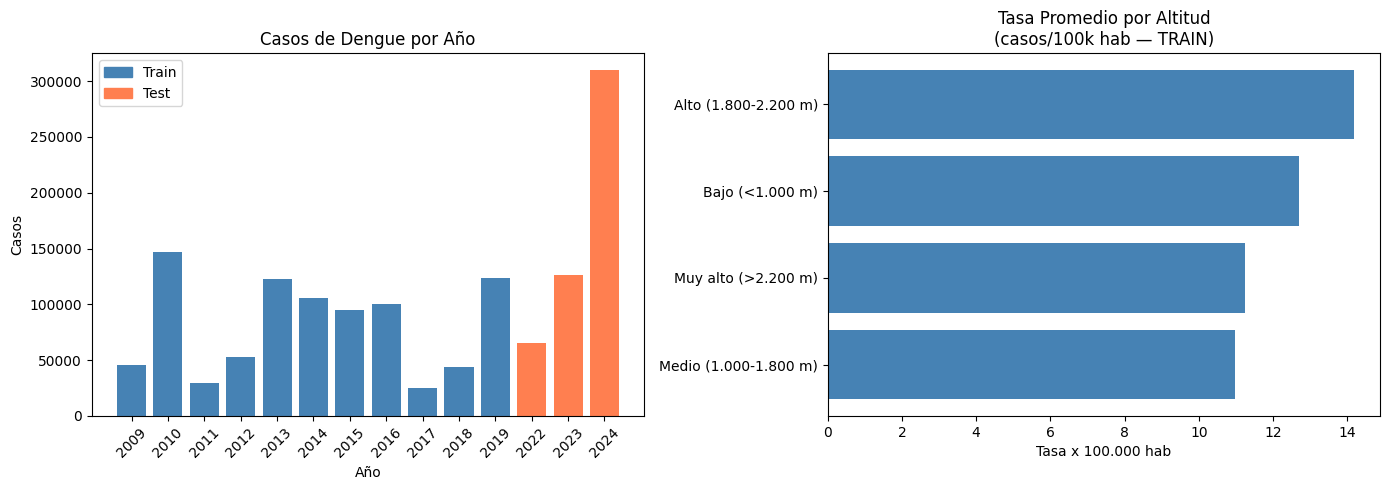

✅ Gráfico guardado


In [ ]:
import matplotlib.pyplot as plt

print('=== CASOS POR AÑO ===')
print(df_final.groupby(['anio','split'])['casos'].sum().to_string())

print('\n=== CASOS POR CATEGORÍA ALTITUDINAL (TRAIN) ===')
print(df_final_train.groupby('cat_altitud')['casos'].sum()
      .sort_values(ascending=False).to_string())

print('\n=== TASA PROMEDIO POR CATEGORÍA ALTITUDINAL (TRAIN) ===')
print(df_final_train.groupby('cat_altitud')['tasa_x100k']
      .mean().sort_values(ascending=False).round(1).to_string())

# Gráfico casos por año
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

casos_año = df_final.groupby(['anio','split'])['casos'].sum().reset_index()
colores = casos_año['split'].map({'train':'steelblue','test':'coral'})
axes[0].bar(casos_año['anio'].astype(str), casos_año['casos'], color=colores)
axes[0].set_title('Casos de Dengue por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Casos')
axes[0].tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='steelblue',label='Train'),
                         Patch(color='coral',label='Test')])

# Tasa por categoría altitudinal
tasa_alt = df_final_train.groupby('cat_altitud')['tasa_x100k'].mean().sort_values()
axes[1].barh(tasa_alt.index, tasa_alt.values, color='steelblue')
axes[1].set_title('Tasa Promedio por Altitud\n(casos/100k hab — TRAIN)')
axes[1].set_xlabel('Tasa x 100.000 hab')

plt.tight_layout()
plt.savefig('resumen_dengue.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado')

## Paso 12 — Exportar CSVs finales

In [ ]:
from google.colab import files

df_final.to_csv('dengue_modelo_final.csv',        index=False, encoding='utf-8-sig')
df_final_train.to_csv('dengue_train_2009_2019.csv', index=False, encoding='utf-8-sig')
df_final_test.to_csv('dengue_test_2022_2024.csv',   index=False, encoding='utf-8-sig')

print('✅ Archivos exportados:')
print(f'   dengue_modelo_final.csv      — {len(df_final):,} filas (train + test)')
print(f'   dengue_train_2009_2019.csv   — {len(df_final_train):,} filas')
print(f'   dengue_test_2022_2024.csv    — {len(df_final_test):,} filas')
print(f'\nColumnas: {df_final.columns.tolist()}')

files.download('dengue_modelo_final.csv')
files.download('dengue_train_2009_2019.csv')
files.download('dengue_test_2022_2024.csv')

✅ Archivos exportados:
   dengue_modelo_final.csv      — 262,569 filas (train + test)
   dengue_train_2009_2019.csv   — 186,400 filas
   dengue_test_2022_2024.csv    — 76,169 filas

Columnas: ['cod_municipio', 'anio', 'semana_epi', 'tipo_dengue', 'casos', 'NOM_MPIO', 'NOM_DPTO', 'altitud_msnm', 'cat_altitud', 'poblacion', 'tasa_x100k', 'split']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Extracción Datos GEE

In [ ]:
# Instalar e inicializar Earth Engine
!pip install earthengine-api --quiet

import ee

ee.Authenticate()
ee.Initialize(project='proyecto-grado-bitbusters')

print('✅ Earth Engine inicializado')

✅ Earth Engine inicializado


In [ ]:
import ee
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import requests
import io
from tqdm import tqdm

# ── Configuración ─────────────────────────────────────────────────────────────
AÑOS_TRAIN = list(range(2009, 2020))
AÑOS_TEST  = [2022, 2023, 2024]
AÑOS       = AÑOS_TRAIN + AÑOS_TEST

# ── Cargar municipios de Colombia desde DIVIPOLA ──────────────────────────────
print('Cargando DIVIPOLA...')
URL_DIVIPOLA = 'https://www.datos.gov.co/api/views/vafm-j2df/rows.csv?accessType=DOWNLOAD'
df_div = pd.read_csv(URL_DIVIPOLA, low_memory=False)
df_div = df_div[['COD_MPIO','NOM_MPIO','NOM_DPTO','LATITUD','LONGITUD']].copy()
df_div['LATITUD']  = pd.to_numeric(df_div['LATITUD'],  errors='coerce')
df_div['LONGITUD'] = pd.to_numeric(df_div['LONGITUD'], errors='coerce')
df_div = df_div.dropna(subset=['LATITUD','LONGITUD'])
df_div['cod_municipio'] = df_div['COD_MPIO'].astype(int).astype(str).str.zfill(5)
print(f'✅ {len(df_div)} municipios cargados')

# ── Función: obtener semanas epidemiológicas de un año ────────────────────────
def get_semanas_epi(año):
    """Genera fechas inicio/fin de cada semana epidemiológica del año."""
    semanas = []
    # Semana 1 comienza el primer domingo del año
    fecha = datetime(año, 1, 1)
    # Ajustar al primer domingo
    while fecha.weekday() != 6:  # 6 = domingo
        fecha += timedelta(days=1)
    # Retroceder si el año empieza antes del domingo
    inicio = datetime(año, 1, 1)
    if inicio.weekday() != 6:
        inicio = fecha - timedelta(weeks=1)
        if inicio.year < año:
            inicio = fecha

    semana = 1
    current = datetime(año, 1, 1)
    # Inicio real: domingo antes o igual al 1 de enero
    dow = current.weekday()  # 0=lunes, 6=domingo
    days_to_sunday = (6 - dow) % 7
    if days_to_sunday > 0:
        current = current - timedelta(days=(dow + 1) % 7)

    while current.year <= año and semana <= 53:
        fin = current + timedelta(days=6)
        if current.year == año or fin.year == año:
            semanas.append({
                'año': año,
                'semana_epi': semana,
                'fecha_inicio': current.strftime('%Y-%m-%d'),
                'fecha_fin': min(fin, datetime(año, 12, 31)).strftime('%Y-%m-%d')
            })
        current += timedelta(weeks=1)
        semana += 1
        if current.year > año:
            break

    return semanas

# ── Función: extraer clima por punto y período ────────────────────────────────
def extraer_clima_municipio(lat, lon, fecha_inicio, fecha_fin):
    """
    Extrae temperatura media, precipitación total y humedad media
    para un punto (lat, lon) en un período dado.
    """
    punto = ee.Geometry.Point([lon, lat])

    try:
        # Temperatura y humedad — ERA5-Land
        era5 = (ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
                .filterDate(fecha_inicio, fecha_fin)
                .select(['temperature_2m', 'dewpoint_temperature_2m']))

        # Temperatura media en Celsius
        temp = (era5.select('temperature_2m')
                .mean()
                .reduceRegion(ee.Reducer.mean(), punto, 10000)
                .getInfo())
        temp_c = temp.get('temperature_2m', None)
        if temp_c is not None:
            temp_c = temp_c - 273.15  # Kelvin a Celsius

        # Humedad relativa aproximada desde temperatura de punto de rocío
        dew = (era5.select('dewpoint_temperature_2m')
               .mean()
               .reduceRegion(ee.Reducer.mean(), punto, 10000)
               .getInfo())
        dew_c = dew.get('dewpoint_temperature_2m', None)
        humedad = None
        if temp_c is not None and dew_c is not None:
            dew_c = dew_c - 273.15
            # Fórmula aproximada de humedad relativa
            humedad = 100 * np.exp((17.625 * dew_c) / (243.04 + dew_c)) / \
                            np.exp((17.625 * temp_c) / (243.04 + temp_c))

        # Precipitación — CHIRPS
        chirps = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
                  .filterDate(fecha_inicio, fecha_fin)
                  .select('precipitation'))
        precip = (chirps.sum()
                  .reduceRegion(ee.Reducer.mean(), punto, 10000)
                  .getInfo())
        precip_mm = precip.get('precipitation', None)

        return temp_c, humedad, precip_mm

    except Exception as e:
        return None, None, None

# ── Prueba con Bogotá para verificar que funciona ─────────────────────────────
print('\nProbando extracción climática con Bogotá semana 1 de 2018...')
temp, hum, prec = extraer_clima_municipio(4.711, -74.072, '2018-01-01', '2018-01-07')
print(f'  Temperatura: {temp:.1f} °C' if temp else '  Temperatura: N/A')
print(f'  Humedad    : {hum:.1f} %'   if hum  else '  Humedad: N/A')
print(f'  Precipit.  : {prec:.1f} mm' if prec else '  Precipitación: N/A')

Cargando DIVIPOLA...
✅ 1121 municipios cargados

Probando extracción climática con Bogotá semana 1 de 2018...
  Temperatura: 13.3 °C
  Humedad    : 84.1 %
  Precipit.  : 8.8 mm


In [ ]:
# ── Extracción eficiente por año y semana usando featureCollection ────────────

def extraer_clima_semana(año, semana, fecha_inicio, fecha_fin, df_municipios):
    """
    Extrae clima para TODOS los municipios en una semana de una sola vez
    usando ee.FeatureCollection — mucho más eficiente que punto por punto.
    """
    # Crear FeatureCollection con todos los municipios
    features = []
    for _, row in df_municipios.iterrows():
        feat = ee.Feature(
            ee.Geometry.Point([row['LONGITUD'], row['LATITUD']]),
            {'cod_municipio': row['cod_municipio']}
        )
        features.append(feat)

    fc = ee.FeatureCollection(features)

    # Temperatura y humedad — ERA5
    era5 = (ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
            .filterDate(fecha_inicio, fecha_fin)
            .select(['temperature_2m', 'dewpoint_temperature_2m'])
            .mean())

    # Precipitación — CHIRPS
    chirps = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
              .filterDate(fecha_inicio, fecha_fin)
              .select('precipitation')
              .sum())

    # Combinar imágenes
    imagen = era5.addBands(chirps)

    # Extraer valores para todos los puntos
    resultado = imagen.reduceRegions(
        collection=fc,
        reducer=ee.Reducer.mean(),
        scale=10000
    )

    # Obtener resultados
    datos = resultado.getInfo()

    registros = []
    for feat in datos['features']:
        props = feat['properties']
        temp_k  = props.get('temperature_2m')
        dew_k   = props.get('dewpoint_temperature_2m')
        precip  = props.get('precipitation')

        temp_c  = temp_k - 273.15 if temp_k else None
        dew_c   = dew_k  - 273.15 if dew_k  else None
        humedad = None
        if temp_c and dew_c:
            humedad = 100 * np.exp((17.625 * dew_c) / (243.04 + dew_c)) / \
                            np.exp((17.625 * temp_c) / (243.04 + temp_c))

        registros.append({
            'cod_municipio' : props.get('cod_municipio'),
            'anio'          : año,
            'semana_epi'    : semana,
            'fecha_inicio'  : fecha_inicio,
            'fecha_fin'     : fecha_fin,
            'temp_media_c'  : round(temp_c,  2) if temp_c  else None,
            'humedad_pct'   : round(humedad, 2) if humedad else None,
            'precip_mm'     : round(precip,  2) if precip  else None,
        })

    return registros

# ── Prueba con UNA semana completa (1.121 municipios) ────────────────────────
print('Probando extracción de una semana completa para todos los municipios...')
print('Esto puede tardar 1-2 minutos...')

registros_prueba = extraer_clima_semana(
    año=2018, semana=1,
    fecha_inicio='2018-01-01', fecha_fin='2018-01-07',
    df_municipios=df_div
)

df_prueba = pd.DataFrame(registros_prueba)
print(f'✅ {len(df_prueba)} municipios extraídos')
print(f'\nEstadísticas semana 1 de 2018:')
print(df_prueba[['temp_media_c','humedad_pct','precip_mm']].describe().round(2))
print(f'\nMuestra:')
print(df_prueba.head(5).to_string())

Probando extracción de una semana completa para todos los municipios...
Esto puede tardar 1-2 minutos...
✅ 1121 municipios extraídos

Estadísticas semana 1 de 2018:
       temp_media_c  humedad_pct  precip_mm
count       1119.00      1119.00    1007.00
mean          19.44        84.55      46.46
std            5.31         5.89      29.68
min            6.53        58.88       3.31
25%           15.24        82.73      26.17
50%           19.18        86.08      40.00
75%           24.92        88.43      59.19
max           28.85        93.90     204.26

Muestra:
  cod_municipio  anio  semana_epi fecha_inicio   fecha_fin  temp_media_c  humedad_pct  precip_mm
0         05001  2018           1   2018-01-01  2018-01-07         15.24        86.62      43.33
1         05002  2018           1   2018-01-01  2018-01-07         14.79        85.85      67.91
2         05004  2018           1   2018-01-01  2018-01-07         14.10        83.25      36.48
3         05021  2018           1   2018-

In [ ]:
import time

# Medir tiempo exacto de una consulta
inicio = time.time()
_ = extraer_clima_semana(
    año=2018, semana=2,
    fecha_inicio='2018-01-08', fecha_fin='2018-01-14',
    df_municipios=df_div
)
fin = time.time()

tiempo_semana = fin - inicio
total_semanas = len(AÑOS) * 52
tiempo_total_horas = (tiempo_semana * total_semanas) / 3600

print(f'Tiempo por semana    : {tiempo_semana:.1f} segundos')
print(f'Total semanas        : {total_semanas}')
print(f'Tiempo estimado total: {tiempo_total_horas:.1f} horas')
print(f'Tiempo estimado total: {tiempo_total_horas*60:.0f} minutos')

Tiempo por semana    : 1.1 segundos
Total semanas        : 728
Tiempo estimado total: 0.2 horas
Tiempo estimado total: 14 minutos


In [ ]:
from tqdm import tqdm
import time

# ── Generar todas las semanas de todos los años ───────────────────────────────
print('Generando calendario de semanas epidemiológicas...')
todas_semanas = []
for año in AÑOS:
    semanas = get_semanas_epi(año)
    todas_semanas.extend(semanas)

print(f'Total semanas a procesar: {len(todas_semanas)}')
print(f'Años: {AÑOS}')

# ── Extracción completa ───────────────────────────────────────────────────────
todos_registros = []
errores = []

for semana_info in tqdm(todas_semanas, desc='Extrayendo clima'):
    año         = semana_info['año']
    semana      = semana_info['semana_epi']
    fecha_ini   = semana_info['fecha_inicio']
    fecha_fin   = semana_info['fecha_fin']

    try:
        registros = extraer_clima_semana(
            año=año,
            semana=semana,
            fecha_inicio=fecha_ini,
            fecha_fin=fecha_fin,
            df_municipios=df_div
        )
        todos_registros.extend(registros)

    except Exception as e:
        print(f'\n⚠️ Error en {año} semana {semana}: {e}')
        errores.append({'año': año, 'semana': semana, 'error': str(e)})
        time.sleep(5)  # pausa antes de continuar
        continue

# ── Resultado final ───────────────────────────────────────────────────────────
df_clima = pd.DataFrame(todos_registros)

print(f'\n✅ Extracción completada')
print(f'   Registros totales : {len(df_clima):,}')
print(f'   Municipios únicos : {df_clima["cod_municipio"].nunique()}')
print(f'   Años cubiertos    : {sorted(df_clima["anio"].unique())}')
print(f'   Errores           : {len(errores)}')
print(f'\nEstadísticas generales:')
print(df_clima[['temp_media_c','humedad_pct','precip_mm']].describe().round(2))

# ── Exportar ──────────────────────────────────────────────────────────────────
df_clima.to_csv('clima_municipios_colombia.csv', index=False, encoding='utf-8-sig')
print('\n✅ Guardado: clima_municipios_colombia.csv')

from google.colab import files
files.download('clima_municipios_colombia.csv')

Generando calendario de semanas epidemiológicas...
Total semanas a procesar: 742
Años: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024]


Extrayendo clima:  64%|██████▍   | 476/742 [04:23<02:18,  1.93it/s]


⚠️ Error en 2017 semana 53: Empty date ranges not supported for the current operation.


Extrayendo clima:  93%|█████████▎| 688/742 [06:27<00:32,  1.64it/s]


⚠️ Error en 2023 semana 53: Empty date ranges not supported for the current operation.


Extrayendo clima: 100%|██████████| 742/742 [07:01<00:00,  1.76it/s]



✅ Extracción completada
   Registros totales : 829,540
   Municipios únicos : 1121
   Años cubiertos    : [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]
   Errores           : 2

Estadísticas generales:
       temp_media_c  humedad_pct  precip_mm
count     828060.00    828060.00  677173.00
mean          20.02        81.84      41.71
std            5.48         9.31      34.65
min            4.34        26.47       0.00
25%           15.70        77.57      16.71
50%           19.85        84.34      32.78
75%           25.07        88.38      56.66
max           34.05        99.31     544.11

✅ Guardado: clima_municipios_colombia.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cruce 4 fuentes en colab

In [ ]:
import gdown
import os
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
import requests
import io

# ── 1. Cargar clima desde Drive ───────────────────────────────────────────────
FOLDER_ID_DATOS = '1jp2S5jh6qIewo6xttZZNlv7IFbykUYXc'
ARCHIVO_CLIMA   = 'clima_municipios_colombia.csv'

if not os.path.exists(ARCHIVO_CLIMA):
    print('Descargando clima desde Drive...')
    gdown.download(
        f'https://drive.google.com/uc?id={FOLDER_ID_DATOS}',
        ARCHIVO_CLIMA, quiet=False
    )
else:
    print('✅ Clima ya existe')

df_clima = pd.read_csv(ARCHIVO_CLIMA)
df_clima['cod_municipio'] = df_clima['cod_municipio'].astype(str).str.zfill(5)
df_clima['anio']          = pd.to_numeric(df_clima['anio'],       errors='coerce')
df_clima['semana_epi']    = pd.to_numeric(df_clima['semana_epi'], errors='coerce')

print(f'✅ Clima: {len(df_clima):,} registros')
print(f'   Años: {sorted(df_clima["anio"].unique())}')


✅ Clima ya existe
✅ Clima: 829,540 registros
   Años: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
import gdown
import pandas as pd

# Descargar dengue_modelo_final
gdown.download('https://drive.google.com/uc?id=1aqO4ezCm4JXAfF0gBersSTc4WeSYfOgC',
               'dengue_modelo_final.csv', quiet=False)

df = pd.read_csv('dengue_modelo_final.csv')
print(f'Dimensiones: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
print(f'Años: {sorted(df["anio"].unique()) if "anio" in df.columns else "N/A"}')
print(f'Municipios: {df["cod_municipio"].nunique() if "cod_municipio" in df.columns else "N/A"}')
df.head(3)

Downloading...
From: https://drive.google.com/uc?id=1aqO4ezCm4JXAfF0gBersSTc4WeSYfOgC
To: /content/dengue_modelo_final.csv
100%|██████████| 22.8M/22.8M [00:00<00:00, 154MB/s] 


Dimensiones: (262569, 12)
Columnas: ['cod_municipio', 'anio', 'semana_epi', 'tipo_dengue', 'casos', 'NOM_MPIO', 'NOM_DPTO', 'altitud_msnm', 'cat_altitud', 'poblacion', 'tasa_x100k', 'split']
Años: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]
Municipios: 1165


,cod_municipio,anio,semana_epi,tipo_dengue,casos,NOM_MPIO,NOM_DPTO,altitud_msnm,cat_altitud,poblacion,tasa_x100k,split
0,1000,2009,20,grave,1,NaN,NaN,NaN,NaN,NaN,NaN,train
1,1000,2009,27,grave,1,NaN,NaN,NaN,NaN,NaN,NaN,train
2,1000,2009,50,con_alarma,1,NaN,NaN,NaN,NaN,NaN,NaN,train


In [ ]:
import gdown
import pandas as pd
import numpy as np

# ── 1. Cargar clima ───────────────────────────────────────────────────────────
gdown.download('https://drive.google.com/uc?id=14sD8eZatRnDcNpji9bv5Ltxk4XwrjEwE',
               'clima_municipios_colombia.csv', quiet=False)

df_clima = pd.read_csv('clima_municipios_colombia.csv')
df_clima['cod_municipio'] = df_clima['cod_municipio'].astype(str).str.zfill(5)
df_clima['anio']          = pd.to_numeric(df_clima['anio'],       errors='coerce')
df_clima['semana_epi']    = pd.to_numeric(df_clima['semana_epi'], errors='coerce')

print(f'✅ Clima: {len(df_clima):,} registros')

# ── 2. Preparar dengue ────────────────────────────────────────────────────────
df = pd.read_csv('dengue_modelo_final.csv')
df['cod_municipio'] = df['cod_municipio'].astype(str).str.zfill(5)
df['anio']          = pd.to_numeric(df['anio'],       errors='coerce')
df['semana_epi']    = pd.to_numeric(df['semana_epi'], errors='coerce')

# Eliminar municipios inválidos (sin nombre)
df = df[df['NOM_MPIO'].notna()].copy()
print(f'✅ Dengue limpio: {len(df):,} filas')

# ── 3. Cruce con clima ────────────────────────────────────────────────────────
df = df.merge(
    df_clima[['cod_municipio','anio','semana_epi',
              'temp_media_c','humedad_pct','precip_mm']],
    on=['cod_municipio','anio','semana_epi'],
    how='left'
)

print(f'✅ Cruce completado: {len(df):,} filas')
print(f'   Con clima: {df["temp_media_c"].notna().sum():,}')
print(f'   Sin clima: {df["temp_media_c"].isna().sum():,}')

# ── 4. Agregar rezagos climáticos ─────────────────────────────────────────────
print('\nAgregando rezagos...')
df = df.sort_values(['cod_municipio', 'anio', 'semana_epi'])

for lag in [2, 3, 4]:
    df[f'temp_lag{lag}']   = df.groupby('cod_municipio')['temp_media_c'].shift(lag)
    df[f'precip_lag{lag}'] = df.groupby('cod_municipio')['precip_mm'].shift(lag)

for lag in [1, 2, 3]:
    df[f'humedad_lag{lag}'] = df.groupby('cod_municipio')['humedad_pct'].shift(lag)

# ── 5. Resumen final ──────────────────────────────────────────────────────────
print(f'\n✅ Dataset final completo')
print(f'   Filas totales  : {len(df):,}')
print(f'   Municipios     : {df["cod_municipio"].nunique()}')
print(f'   Años           : {sorted(df["anio"].unique())}')
print(f'   Con altitud    : {df["altitud_msnm"].notna().sum():,}')
print(f'   Con población  : {df["poblacion"].notna().sum():,}')
print(f'   Con clima      : {df["temp_media_c"].notna().sum():,}')
print(f'   Con tasa       : {df["tasa_x100k"].notna().sum():,}')
print(f'\nColumnas: {df.columns.tolist()}')

print('\nEstadísticas clima:')
print(df[['temp_media_c','humedad_pct','precip_mm']].describe().round(2))

# ── 6. Exportar ───────────────────────────────────────────────────────────────
TRAIN = df[df['split'] == 'train']
TEST  = df[df['split'] == 'test']

df.to_csv('dataset_dengue_completo.csv',    index=False, encoding='utf-8-sig')
TRAIN.to_csv('dataset_train_2009_2019.csv', index=False, encoding='utf-8-sig')
TEST.to_csv('dataset_test_2022_2024.csv',   index=False, encoding='utf-8-sig')

print(f'\n✅ Archivos exportados:')
print(f'   dataset_dengue_completo.csv    → {len(df):,} filas')
print(f'   dataset_train_2009_2019.csv    → {len(TRAIN):,} filas')
print(f'   dataset_test_2022_2024.csv     → {len(TEST):,} filas')

from google.colab import files
files.download('dataset_dengue_completo.csv')
files.download('dataset_train_2009_2019.csv')
files.download('dataset_test_2022_2024.csv')

Downloading...
From: https://drive.google.com/uc?id=14sD8eZatRnDcNpji9bv5Ltxk4XwrjEwE
To: /content/clima_municipios_colombia.csv
100%|██████████| 43.6M/43.6M [00:00<00:00, 113MB/s]


✅ Clima: 829,540 registros
✅ Dengue limpio: 257,482 filas
✅ Cruce completado: 257,482 filas
   Con clima: 256,990
   Sin clima: 492

Agregando rezagos...

✅ Dataset final completo
   Filas totales  : 257,482
   Municipios     : 1070
   Años           : [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]
   Con altitud    : 257,482
   Con población  : 109,442
   Con clima      : 256,990
   Con tasa       : 109,442

Columnas: ['cod_municipio', 'anio', 'semana_epi', 'tipo_dengue', 'casos', 'NOM_MPIO', 'NOM_DPTO', 'altitud_msnm', 'cat_altitud', 'poblacion', 'tasa_x100k', 'split', 'temp_media_c', 'humedad_pct', 'precip_mm', 'temp_lag2', 'precip_lag2', 'temp_lag3', 'precip_lag3', 'temp_lag4', 'precip_lag4', 'humedad_lag1', 'humedad_lag2', 'humedad_lag3']

Estadísticas clima:
       temp_media_c  humedad_pct  precip_mm
cou

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Diagnóstico de municipios sin población ───────────────────────────────────
df_sin_pob = df[df['poblacion'].isna()].copy()
df_con_pob = df[df['poblacion'].notna()].copy()

print(f'Sin población: {len(df_sin_pob):,} filas')
print(f'Con población: {len(df_con_pob):,} filas')

print(f'\nMunicipios únicos sin población: {df_sin_pob["cod_municipio"].nunique()}')
print(f'Municipios únicos con población: {df_con_pob["cod_municipio"].nunique()}')

print('\n--- Top 20 municipios sin población ---')
top_sin = (df_sin_pob.groupby(['cod_municipio','NOM_MPIO','NOM_DPTO'])['casos']
           .sum().reset_index()
           .sort_values('casos', ascending=False)
           .head(20))
print(top_sin.to_string())

print('\n--- Departamentos afectados ---')
print(df_sin_pob.groupby('NOM_DPTO')['casos'].sum()
      .sort_values(ascending=False).to_string())

Sin población: 148,040 filas
Con población: 109,442 filas

Municipios únicos sin población: 1054
Municipios únicos con población: 1013

--- Top 20 municipios sin población ---
    cod_municipio             NOM_MPIO            NOM_DPTO  casos
942         76001                 CALI     VALLE DEL CAUCA  80382
0           05001             MEDELLÍN           ANTIOQUIA  45956
895         73001               IBAGUÉ              TOLIMA  27715
782         68001          BUCARAMANGA           SANTANDER  26678
716         54001   SAN JOSÉ DE CÚCUTA  NORTE DE SANTANDER  24691
631         50001        VILLAVICENCIO                META  22544
549         41001                NEIVA               HUILA  16494
814         68276        FLORIDABLANCA           SANTANDER  15556
125         08001         BARRANQUILLA           ATLÁNTICO  15034
756         63001              ARMENIA             QUINDÍO  12020
768         66001              PEREIRA           RISARALDA  11014
869         70001            SIN

In [ ]:
# Verificar el código de Cali en cada fuente
print('=== Cali en df (SIVIGILA) ===')
print(df[df['NOM_MPIO'] == 'CALI'][['cod_municipio','NOM_MPIO','poblacion']].drop_duplicates().head())

print('\n=== Cali en df_pob (DANE) ===')
print(df_pob[df_pob['cod_municipio'].str.contains('76001')][['cod_municipio','anio','poblacion']].head())

print('\n=== Medellín en df (SIVIGILA) ===')
print(df[df['NOM_MPIO'] == 'MEDELLÍN'][['cod_municipio','NOM_MPIO','poblacion']].drop_duplicates().head())

print('\n=== Medellín en df_pob (DANE) ===')
print(df_pob[df_pob['cod_municipio'].str.contains('05001')][['cod_municipio','anio','poblacion']].head())

print('\n=== Tipos de datos ===')
print(f'df cod_municipio dtype: {df["cod_municipio"].dtype}')
print(f'df_pob cod_municipio dtype: {df_pob["cod_municipio"].dtype}')

print('\n=== Ejemplos códigos en df ===')
print(df['cod_municipio'].head(10).tolist())

print('\n=== Ejemplos códigos en df_pob ===')
print(df_pob['cod_municipio'].head(10).tolist())

=== Cali en df (SIVIGILA) ===
       cod_municipio NOM_MPIO  poblacion
153009         76001     CALI        NaN
154192         76001     CALI  2227649.0
154302         76001     CALI  2248066.0
245655         76001     CALI  2283342.0
245763         76001     CALI  2280485.0

=== Cali en df_pob (DANE) ===
      cod_municipio  anio  poblacion
15592         76001  2018    2227649
16715         76001  2019    2248066
20084         76001  2022    2283342
21207         76001  2023    2280485
22330         76001  2024    2280171

=== Medellín en df (SIVIGILA) ===
       cod_municipio  NOM_MPIO  poblacion
0              05001  MEDELLÍN        NaN
1032           05001  MEDELLÍN  2427133.0
1142           05001  MEDELLÍN  2455336.0
181925         05001  MEDELLÍN  2514709.0
182017         05001  MEDELLÍN  2518480.0

=== Medellín en df_pob (DANE) ===
      cod_municipio  anio  poblacion
14586         05001  2018    2427133
15709         05001  2019    2455336
19078         05001  2022    2514709
2

In [ ]:
# ── Diagnóstico df_pob ────────────────────────────────────────────────────────
print('Columnas df_pob:', df_pob.columns.tolist())
print('\nPrimeras filas df_pob:')
print(df_pob.head(10).to_string())


Columnas df_pob: ['cod_municipio', 'anio', 'poblacion']

Primeras filas df_pob:
     cod_municipio  anio  poblacion
4488      Medellín  2009    2157094
4489     Abejorral  2009      22026
4490      Abriaquí  2009       2663
4491    Alejandría  2009       4694
4492         Amagá  2009      27920
4493        Amalfi  2009      23772
4494         Andes  2009      42074
4495   Angelópolis  2009       5793
4496     Angostura  2009      11912
4497         Anorí  2009      16573


In [ ]:
import requests, io

# ── Recargar DANE 2005-2017 con las columnas correctas ────────────────────────
print('Recargando DANE 2005-2017...')
URL_05_17 = 'https://www.dane.gov.co/files/censo2018/proyecciones-de-poblacion/Municipal/DCD-area-proypoblacion-Mun-2005-2017_VP.xlsx'
resp = requests.get(URL_05_17, timeout=120, headers={'User-Agent': 'Mozilla/5.0'})
df_raw = pd.read_excel(io.BytesIO(resp.content), sheet_name='NuevaMpal')

# Ver las columnas reales alrededor de la fila 10
print('Fila 10 (encabezados):')
print(df_raw.iloc[10].tolist())
print('\nFila 11 (primera fila de datos):')
print(df_raw.iloc[11].tolist())


Recargando DANE 2005-2017...
Fila 10 (encabezados):
['DP', 'DPNOM', 'DPMP', 'MPIO', 'AÑO', 'ÁREA GEOGRÁFICA', 'Población']

Fila 11 (primera fila de datos):
['05', 'Antioquia', 'Medellín', '05001', 2005, 'Cabecera Municipal', 1997763]


In [ ]:
import requests, io

# ── Recargar DANE 2005-2017 con columna correcta (MPIO) ──────────────────────
print('Recargando DANE 2005-2017...')
URL_05_17 = 'https://www.dane.gov.co/files/censo2018/proyecciones-de-poblacion/Municipal/DCD-area-proypoblacion-Mun-2005-2017_VP.xlsx'
resp = requests.get(URL_05_17, timeout=120, headers={'User-Agent': 'Mozilla/5.0'})
df_raw_05 = pd.read_excel(io.BytesIO(resp.content), sheet_name='NuevaMpal')

df_raw_05.columns = df_raw_05.iloc[10].tolist()
df_raw_05 = df_raw_05.iloc[11:].reset_index(drop=True)
df_raw_05 = df_raw_05[df_raw_05['ÁREA GEOGRÁFICA'] == 'Total'].copy()
df_raw_05 = df_raw_05.rename(columns={
    'MPIO'      : 'cod_municipio',
    'AÑO'       : 'anio',
    'Población' : 'poblacion'
})
df_raw_05['cod_municipio'] = df_raw_05['cod_municipio'].astype(str).str.zfill(5)
df_raw_05['anio']          = pd.to_numeric(df_raw_05['anio'],      errors='coerce')
df_raw_05['poblacion']     = pd.to_numeric(df_raw_05['poblacion'], errors='coerce')
df_pob_05 = df_raw_05[['cod_municipio','anio','poblacion']].dropna()

print(f'✅ 2005-2017: {len(df_pob_05):,} registros')
print(f'   Ejemplo: {df_pob_05.head(3).to_string()}')

# ── Recargar DANE 2018-2042 ───────────────────────────────────────────────────
print('\nRecargando DANE 2018-2042...')
URL_18_42 = 'https://www.dane.gov.co/files/censo2018/proyecciones-de-poblacion/Municipal/PPED-AreaMun-2018-2042_VP.xlsx'
resp2 = requests.get(URL_18_42, timeout=120, headers={'User-Agent': 'Mozilla/5.0'})
df_raw_18 = pd.read_excel(io.BytesIO(resp2.content), sheet_name='PobMunicipalxÁrea')

df_raw_18.columns = df_raw_18.iloc[6].tolist()
df_raw_18 = df_raw_18.iloc[7:].reset_index(drop=True)
df_raw_18 = df_raw_18[df_raw_18['ÁREA GEOGRÁFICA'] == 'Total'].copy()
df_raw_18 = df_raw_18.rename(columns={
    'MPIO'  : 'cod_municipio',
    'AÑO'   : 'anio',
    'TOTAL' : 'poblacion'
})
df_raw_18['cod_municipio'] = df_raw_18['cod_municipio'].astype(str).str.zfill(5)
df_raw_18['anio']          = pd.to_numeric(df_raw_18['anio'],      errors='coerce')
df_raw_18['poblacion']     = pd.to_numeric(df_raw_18['poblacion'], errors='coerce')
df_pob_18 = df_raw_18[['cod_municipio','anio','poblacion']].dropna()

print(f'✅ 2018-2042: {len(df_pob_18):,} registros')
print(f'   Ejemplo: {df_pob_18.head(3).to_string()}')

# ── Unir ambos períodos ───────────────────────────────────────────────────────
AÑOS_TRAIN = list(range(2009, 2020))
AÑOS_TEST  = [2022, 2023, 2024]

df_pob_nuevo = pd.concat([df_pob_05, df_pob_18], ignore_index=True)
df_pob_nuevo = df_pob_nuevo[df_pob_nuevo['anio'].isin(AÑOS_TRAIN + AÑOS_TEST)]

print(f'\n✅ Población consolidada: {len(df_pob_nuevo):,} registros')
print(f'   Años: {sorted(df_pob_nuevo["anio"].unique())}')
print(f'   Municipios: {df_pob_nuevo["cod_municipio"].nunique()}')
print(f'\n   Ejemplo Cali:')
print(df_pob_nuevo[df_pob_nuevo['cod_municipio'] == '76001'].head(5).to_string())

Recargando DANE 2005-2017...
✅ 2005-2017: 14,586 registros
   Ejemplo:   cod_municipio  anio  poblacion
2         05001  2005    2046341
5         05002  2005      22942
8         05004  2005       2719

Recargando DANE 2018-2042...
✅ 2018-2042: 28,075 registros
   Ejemplo:   cod_municipio  anio  poblacion
3         05001  2018    2427133
6         05002  2018      20368
9         05004  2018       2718

✅ Población consolidada: 15,713 registros
   Años: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]
   Municipios: 1123

   Ejemplo Cali:
     cod_municipio  anio  poblacion
5493         76001  2009    2135980
6615         76001  2010    2146535
7737         76001  2011    2156926
8859         76001  2012    2165625
9981         76001  2013    2172204


In [ ]:
# ── Cruce final con población corregida ───────────────────────────────────────
print('Rehaciendo cruce con población corregida...')

# Recargar dengue base (sin población)
df_base = pd.read_csv('dengue_modelo_final.csv')
df_base['cod_municipio'] = df_base['cod_municipio'].astype(str).str.zfill(5)
df_base['anio']          = pd.to_numeric(df_base['anio'],       errors='coerce')
df_base['semana_epi']    = pd.to_numeric(df_base['semana_epi'], errors='coerce')

# Eliminar municipios inválidos
df_base = df_base[df_base['NOM_MPIO'].notna()].copy()

# Quitar población y tasa anteriores (incorrectas)
df_base = df_base.drop(columns=['poblacion', 'tasa_x100k'], errors='ignore')

# ── Cruce con población corregida ─────────────────────────────────────────────
df_base = df_base.merge(
    df_pob_nuevo[['cod_municipio', 'anio', 'poblacion']],
    on=['cod_municipio', 'anio'],
    how='left'
)

# Calcular tasa
df_base['tasa_x100k'] = (df_base['casos'] / df_base['poblacion']) * 100000

print(f'Con población: {df_base["poblacion"].notna().sum():,}')
print(f'Sin población: {df_base["poblacion"].isna().sum():,}')

# ── Cruce con clima ───────────────────────────────────────────────────────────
df_final = df_base.merge(
    df_clima[['cod_municipio','anio','semana_epi',
              'temp_media_c','humedad_pct','precip_mm']],
    on=['cod_municipio','anio','semana_epi'],
    how='left'
)

# ── Rezagos climáticos ────────────────────────────────────────────────────────
df_final = df_final.sort_values(['cod_municipio','anio','semana_epi'])

for lag in [2, 3, 4]:
    df_final[f'temp_lag{lag}']   = df_final.groupby('cod_municipio')['temp_media_c'].shift(lag)
    df_final[f'precip_lag{lag}'] = df_final.groupby('cod_municipio')['precip_mm'].shift(lag)

for lag in [1, 2, 3]:
    df_final[f'humedad_lag{lag}'] = df_final.groupby('cod_municipio')['humedad_pct'].shift(lag)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f'\n✅ Dataset final corregido')
print(f'   Filas totales  : {len(df_final):,}')
print(f'   Municipios     : {df_final["cod_municipio"].nunique()}')
print(f'   Años           : {sorted(df_final["anio"].unique())}')
print(f'   Con altitud    : {df_final["altitud_msnm"].notna().sum():,}')
print(f'   Con población  : {df_final["poblacion"].notna().sum():,}')
print(f'   Con clima      : {df_final["temp_media_c"].notna().sum():,}')
print(f'   Con tasa       : {df_final["tasa_x100k"].notna().sum():,}')

# Verificar Cali y Medellín
print('\n=== Verificación Cali (76001) ===')
print(df_final[df_final['cod_municipio']=='76001'][
    ['cod_municipio','anio','semana_epi','casos','poblacion','tasa_x100k','temp_media_c']
].head(5).to_string())

print('\n=== Verificación Medellín (05001) ===')
print(df_final[df_final['cod_municipio']=='05001'][
    ['cod_municipio','anio','semana_epi','casos','poblacion','tasa_x100k','temp_media_c']
].head(5).to_string())

# ── Exportar ──────────────────────────────────────────────────────────────────
TRAIN = df_final[df_final['split'] == 'train']
TEST  = df_final[df_final['split'] == 'test']

df_final.to_csv('dataset_dengue_completo.csv',    index=False, encoding='utf-8-sig')
TRAIN.to_csv('dataset_train_2009_2019.csv',       index=False, encoding='utf-8-sig')
TEST.to_csv('dataset_test_2022_2024.csv',         index=False, encoding='utf-8-sig')

print(f'\n✅ Archivos exportados:')
print(f'   dataset_dengue_completo.csv  → {len(df_final):,} filas')
print(f'   dataset_train_2009_2019.csv  → {len(TRAIN):,} filas')
print(f'   dataset_test_2022_2024.csv   → {len(TEST):,} filas')
print(f'\nColumnas: {df_final.columns.tolist()}')

from google.colab import files
files.download('dataset_dengue_completo.csv')
files.download('dataset_train_2009_2019.csv')
files.download('dataset_test_2022_2024.csv')

Rehaciendo cruce con población corregida...
Con población: 257,482
Sin población: 0

✅ Dataset final corregido
   Filas totales  : 257,482
   Municipios     : 1070
   Años           : [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]
   Con altitud    : 257,482
   Con población  : 257,482
   Con clima      : 256,990
   Con tasa       : 257,482

=== Verificación Cali (76001) ===
       cod_municipio  anio  semana_epi  casos  poblacion  tasa_x100k  temp_media_c
153009         76001  2009           1      2    2135980    0.093634         17.79
153010         76001  2009           1     20    2135980    0.936338         17.79
153011         76001  2009           2     10    2135980    0.468169         18.08
153012         76001  2009           2     19    2135980    0.889521         18.08
153013         76001  2009   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>